In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
# Load the CSV file
data = pd.read_csv('sensor data.csv')

In [4]:
data.head()

,Temperature,Humidity,LightIntensity,Label
0,30.2,79,426,0
1,30.2,77,427,1
2,30.2,78,428,0
3,30.2,79,429,1
4,30.2,78,430,0


In [5]:
# Fix column names (remove leading/trailing spaces)
data.columns = data.columns.str.strip()

In [6]:
# Now check the real column names
print(data.columns)

Index(['Temperature', 'Humidity', 'LightIntensity', 'Label'], dtype='object')


In [7]:
data.head()

,Temperature,Humidity,LightIntensity,Label
0,30.2,79,426,0
1,30.2,77,427,1
2,30.2,78,428,0
3,30.2,79,429,1
4,30.2,78,430,0


In [8]:
# Feature and target selection
X = data[['Temperature', 'Humidity', 'LightIntensity']]
y = data['Label']  # Make sure this name exists after cleaning!

In [9]:
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
# Logistic Regression Model
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [11]:
# Predict on test data
y_pred = model.predict(X_test)

In [12]:
# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.513184584178499

Confusion Matrix:
 [[253   0]
 [240   0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.51      1.00      0.68       253
           1       0.00      0.00      0.00       240

    accuracy                           0.51       493
   macro avg       0.26      0.50      0.34       493
weighted avg       0.26      0.51      0.35       493



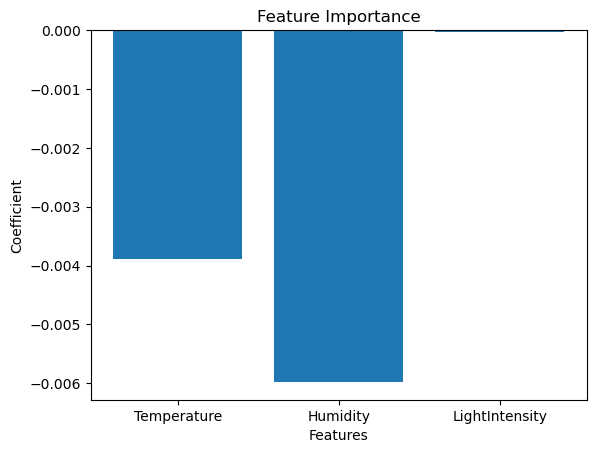

In [13]:
# Optional: Plot feature importance (coefficients)
coefficients = model.coef_[0]
features = X.columns
plt.bar(features, coefficients)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Coefficient")
plt.show()

In [14]:
data = pd.read_csv('weather_data14.csv')

In [15]:
data.head()

,MaxTemp,mintemp,Humditiy,WindSpeed,Label
0,24.790001,14.72,79.0,5.8,0
1,23.580000,15.72,77.0,8.1,1
2,23.850000,14.73,78.0,9.2,0
3,24.680000,15.73,79.0,8.1,1
4,24.639999,16.73,78.0,8.1,0


In [16]:
# Define features and target
X = data[['MaxTemp', 'mintemp', 'Humditiy', 'WindSpeed']]
y = data['Label']

In [17]:
# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
# Create and train the Decision Tree model
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [19]:
# Predict using the test set
y_pred = model.predict(X_test)

In [20]:
# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.4532803180914513

Classification Report:
               precision    recall  f1-score   support

           0       0.48      0.55      0.51       260
           1       0.42      0.35      0.38       243

    accuracy                           0.45       503
   macro avg       0.45      0.45      0.45       503
weighted avg       0.45      0.45      0.45       503



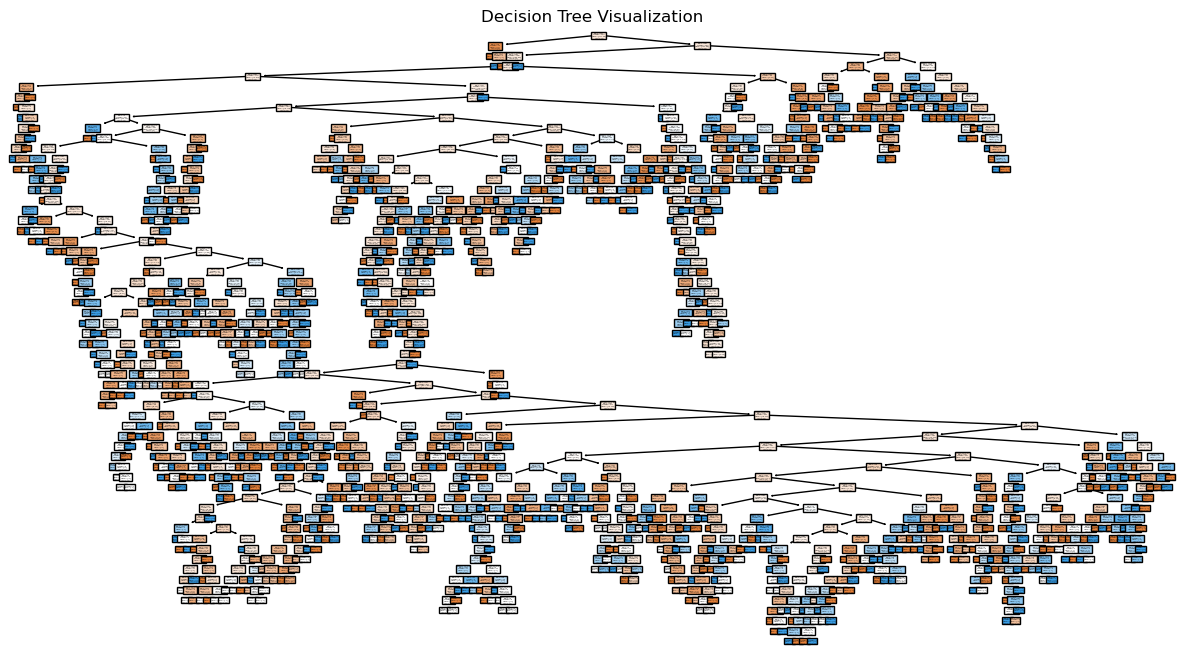

In [21]:
plt.figure(figsize=(15, 8))
plot_tree(model, feature_names=X.columns, class_names=True, filled=True)
plt.title("Decision Tree Visualization")
plt.show()

In [22]:
df = pd.read_csv('Book1.csv')

In [23]:
df.head()

,Temperature,Humidity,LightIntensity
0,30.2,79,426
1,30.2,77,427
2,30.2,78,428
3,30.2,79,429
4,30.2,78,430


In [24]:
# Step 2: Define features (X) and target (y)
X = df[['Temperature', 'Humidity']]  # Independent variables
y = df['LightIntensity'] 

In [25]:
# Step 3: Create and train the model
model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [26]:
# Step 4: Display coefficients
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 1416.4695778515058
Coefficients: [-12.95491407  -4.974293  ]


In [27]:
# Step 5: Predict using the model (optional example)
predicted = model.predict(X)

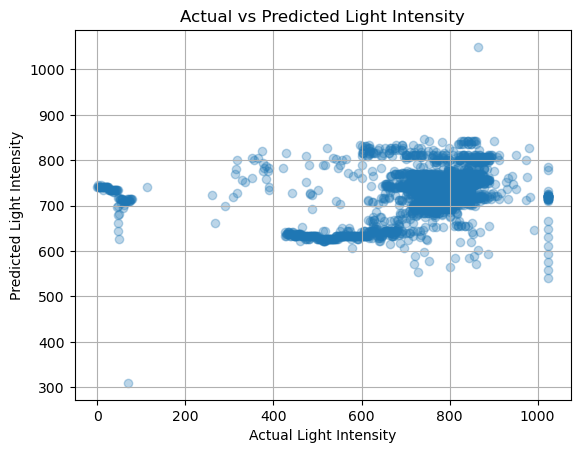

In [28]:
# Step 6: Plot predicted vs actual (optional)
plt.scatter(y, predicted, alpha=0.3)
plt.xlabel("Actual Light Intensity")
plt.ylabel("Predicted Light Intensity")
plt.title("Actual vs Predicted Light Intensity")
plt.grid(True)
plt.show()

In [29]:
# Predict Light Intensity for a new temp and humidity
new_data = [[28, 52]]  # example: 28°C temp, 52% humidity
light_prediction = model.predict(new_data)
print("Predicted Light Intensity:", light_prediction[0])

Predicted Light Intensity: 795.0687479966773
